In [2]:
!pip install -q ultralytics

!pip install -q timm==0.6.13 pytorch-lightning lmdb nltk Levenshtein

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 549.1/549.1 kB 9.2 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.3/338.3 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 59.0 MB/s eta 0:00:00:00:01


In [3]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
from PIL import Image
from glob import glob
from tqdm import tqdm
import Levenshtein
from torchvision import transforms as T
from ultralytics import YOLO

IMAGES_DIR = '/kaggle/input/datasets/princemridul/intern-ocr/temp_dataset/temp_dataset/images'
LABELS_TXT = '/kaggle/input/datasets/princemridul/intern-ocr/temp_dataset/temp_dataset/labels.txt'

YOLO_WEIGHTS = '/kaggle/input/datasets/princemridul/pt-ckpt/best_yolo.pt'
PARSEQ_WEIGHTS = '/kaggle/input/datasets/princemridul/pt-ckpt/last.ckpt'

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
YOLO_CONF_THRESHOLD = 0.25

print(f"Using device: {DEVICE}")
print(f"Images mapped to: {IMAGES_DIR}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Using device: cpu
✅ Images mapped to: /kaggle/input/datasets/princemridul/intern-ocr/temp_dataset/temp_dataset/images


In [4]:
ground_truth_dict = {}
with open(LABELS_TXT, 'r') as f:
    for line in f:
        parts = line.strip().split() # Adjust split(',') if it's comma separated
        if len(parts) >= 2:
            img_name = parts[0]
            label = parts[1]
            ground_truth_dict[img_name] = label

print(f"Loaded {len(ground_truth_dict)} ground truth labels.")


yolo_model = YOLO(YOLO_WEIGHTS)
print("YOLO Model Loaded.")

import sys
import os

# Only clone if the folder isn't already there
if not os.path.exists('/kaggle/working/parseq'):
    !git clone https://github.com/baudm/parseq.git
else:
    print("'parseq' repository already exists, skipping clone.")

sys.path.append('/kaggle/working/parseq')

from strhub.models.parseq.system import PARSeq
parseq_model = PARSeq.load_from_checkpoint(PARSEQ_WEIGHTS).eval().to(DEVICE)

parseq_transform = T.Compose([
    T.Resize((32, 128), T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize(0.5, 0.5)
])

✅ Loaded 3333 ground truth labels.
✅ YOLO Model Loaded.
Cloning into 'parseq'...
remote: Enumerating objects: 612, done.
remote: Counting objects: 100% (311/311), done.
remote: Compressing objects: 100% (118/118), done.
remote: Total 612 (delta 243), reused 193 (delta 193), pack-reused 301 (from 2)
Receiving objects: 100% (612/612), 1.34 MiB | 18.55 MiB/s, done.
Resolving deltas: 100% (344/344), done.


In [5]:
def detect_roi(image_bgr, yolo_model, conf_threshold=0.25):
    results = yolo_model.predict(source=image_bgr, conf=conf_threshold, verbose=False)
    if len(results) == 0 or results[0].boxes is None or len(results[0].boxes) == 0:
        return None
    boxes = results[0].boxes
    best_idx = boxes.conf.argmax().item()
    xyxy = boxes.xyxy[best_idx].cpu().numpy().astype(int)
    conf = boxes.conf[best_idx].item()
    return xyxy, conf

def crop_image(image_bgr, xyxy):
    x1, y1, x2, y2 = xyxy
    h, w = image_bgr.shape[:2]
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w, x2), min(h, y2)
    return image_bgr[y1:y2, x1:x2]

def recognize_text(crop_bgr, parseq_model, img_transform, device):
    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(crop_rgb)
    tensor = img_transform(pil_img).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = parseq_model(tensor)
        probs = logits.softmax(-1)
        labels, confidences = parseq_model.tokenizer.decode(probs)
    return labels[0], (confidences[0].mean().item() if len(confidences[0]) > 0 else 0.0)

def run_pipeline(image_path, yolo_model, parseq_model, img_transform, device):
    result = {"image": os.path.basename(image_path), "status": "OK", "yolo_conf": None, "predicted_text": "", "parseq_conf": None}
    image_bgr = cv2.imread(image_path)
    
    if image_bgr is None:
        result["status"] = "ERROR: Bad Image"
        return result

    detection = detect_roi(image_bgr, yolo_model)
    if detection is None:
        result["status"] = "NO_DETECTION"
        return result

    xyxy, yolo_conf = detection
    result["yolo_conf"] = round(yolo_conf, 4)
    crop = crop_image(image_bgr, xyxy)
    
    if crop.size == 0:
        result["status"] = "EMPTY_CROP"
        return result

    text, parseq_conf = recognize_text(crop, parseq_model, img_transform, device)
    result["predicted_text"] = text
    result["parseq_conf"] = round(parseq_conf, 4)
    return result

In [6]:
results_list = []
ground_truths_list = []
predictions_list = []

# Get all images from the directory
all_images = sorted(glob(os.path.join(IMAGES_DIR, "*.jpg")) + glob(os.path.join(IMAGES_DIR, "*.png")))

print(f"🚀 Benchmarking {len(all_images)} images DIRECTLY through PARSeq...")

for img_path in tqdm(all_images):
    img_name = os.path.basename(img_path)
    
    if img_name not in ground_truth_dict:
        continue
        
    true_text = ground_truth_dict[img_name]
    
    # 1. Initialize a clean result log
    res = {
        "image": img_name,
        "status": "OK",
        "predicted_text": "",
        "parseq_conf": None,
        "ground_truth": true_text
    }
    
    # 2. Read image and bypass YOLO entirely
    image_bgr = cv2.imread(img_path)
    if image_bgr is None or image_bgr.size == 0:
        res["status"] = "ERROR: Bad Image"
        results_list.append(res)
        continue
        
    try:
        # 3. Pass the raw image crop straight to PARSeq
        text, parseq_conf = recognize_text(image_bgr, parseq_model, parseq_transform, DEVICE)
        res["predicted_text"] = text
        res["parseq_conf"] = round(parseq_conf, 4)
        
        pred_text = text
    except Exception as e:
        res["status"] = f"ERROR: {str(e)}"
        pred_text = ""

    # Store data for metrics
    ground_truths_list.append(true_text)
    predictions_list.append(pred_text)
    results_list.append(res)

# --- CALCULATE METRICS ---
exact_matches = 0
total_chars = 0
total_errors = 0

for pred, gt in zip(predictions_list, ground_truths_list):
    if pred == gt:
        exact_matches += 1
    total_errors += Levenshtein.distance(pred, gt)
    total_chars += len(gt)

em_accuracy = (exact_matches / len(predictions_list)) * 100
cer = (total_errors / total_chars) * 100 if total_chars > 0 else 0

print("\n指标📊 --- PARSeq RECOGNITION BENCHMARK ---")
print(f"Total Images Tested: {len(predictions_list)}")
print(f"🎯 Exact Match Accuracy: {em_accuracy:.2f}% ({exact_matches}/{len(predictions_list)} perfectly correct)")
print(f"📉 Character Error Rate (CER): {cer:.2f}%")

# Save the pure OCR report
df_report = pd.DataFrame(results_list)
df_report.to_csv('/kaggle/working/parseq_direct_3333_benchmark.csv', index=False)

🚀 Benchmarking 3333 images DIRECTLY through PARSeq...


  4%|▍         | 127/3333 [00:10<04:36, 11.60it/s]


KeyboardInterrupt: 

In [7]:
!pip install roboflow -q

from roboflow import Roboflow
rf = Roboflow(api_key="Qnj3uwQmrFh75CdE6blG")
project = rf.workspace("7gamil").project("lp7510-numbers-roi-ocr-gia7i")
version = project.version(4)
dataset = version.download("yolov8")

print(f"Dataset downloaded to: {dataset.location}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.3/260.3 kB 5.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 35.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 92.0 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to LP7510-Numbers-ROI-+-OCR-4 in yolov8:: 100%|██████████| 65327/65327 [00:09<00:00, 6839.85it/s] 


✅ Dataset downloaded to: /kaggle/working/LP7510-Numbers-ROI-+-OCR-4


In [ ]:
# 1. Install EasyOCR
!pip install -q easyocr

import os
import pandas as pd
import easyocr
from glob import glob
from tqdm import tqdm

# 2. Setup the reader (using English)
reader = easyocr.Reader(['en'], gpu=False)

# 3. Grab 100 images (using the path from your Roboflow download)
# Make sure IMAGE_DIR matches where your images actually downloaded!
IMAGE_DIR = '/kaggle/working/LP7510-Numbers-ROI-+-OCR-4/valid/images' 
val_images = sorted(glob(os.path.join(IMAGE_DIR, "*.jpg")))[0:100]

labeled_data = []

print("🚀 Auto-Labeling 100 images with EasyOCR...")

# 4. Loop through and guess the text
for img_path in tqdm(val_images):
    img_name = os.path.basename(img_path)
    
    # EasyOCR returns a list of tuples: (bbox, text, confidence)
    result = reader.readtext(img_path)
    
    # Extract the text if it found any, otherwise leave blank
    # Join ALL detected text together with a space
    if len(result) > 0:
        predicted_text = " ".join([res[1] for res in result])
    else:
        predicted_text = ""
        
    labeled_data.append({"filename": img_name, "label": predicted_text})

# 5. Save to CSV
df_auto = pd.DataFrame(labeled_data)
df_auto.to_csv('/kaggle/working/auto_labeled_100.csv', index=False)
print("✅ Done! Download 'auto_labeled_100.csv' and double-check the labels.")

In [ ]:
!pip install Levenshtein -q

In [ ]:
import os
import sys
import cv2
import pandas as pd
import torch
import Levenshtein
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms as T
from ultralytics import YOLO

# 1. SETUP PARSEQ & DEVICE
if not os.path.exists('/kaggle/working/parseq'):
    !git clone https://github.com/baudm/parseq.git
sys.path.append('/kaggle/working/parseq')
from strhub.models.parseq.system import PARSeq

# Use CPU as discussed to save quota, or auto-detect if you flipped the GPU on
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 2. LOAD MODELS
print("📦 Loading YOLO...")
yolo = YOLO('/kaggle/input/datasets/princemridul/pt-ckpt/best_yolo.pt')

print("📦 Loading PARSeq...")
parseq = PARSeq.load_from_checkpoint('/kaggle/input/datasets/princemridul/pt-ckpt/last.ckpt', map_location=DEVICE).eval().to(DEVICE)
parseq_transform = T.Compose([
    T.Resize((32, 128), T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize(0.5, 0.5)
])

# 3. LOAD DATASET
CSV_PATH = '/kaggle/input/datasets/princemridul/labeled-lp7510/auto_labeled_100 (1).csv'
# IMPORTANT: Read as string to keep trailing zeros (e.g., 82.700)
df = pd.read_csv(CSV_PATH, dtype={'label': str})

# Adjust this if your Roboflow images are saved somewhere else!
IMAGE_DIR = '/kaggle/working/LP7510-Numbers-ROI-+-OCR-4/valid/images'

# 4. VISUAL TEST (Image #1)
print("\n🔍 Running visual test on the first image...")
first_row = df.iloc[0]
img_name = first_row['filename']
gt_text = str(first_row['label']).strip()
img_path = os.path.join(IMAGE_DIR, img_name)

img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# YOLO Inference
results = yolo(img_rgb, verbose=False)
boxes = results[0].boxes.xyxy.cpu().numpy()

pred_text = ""
cropped_img = None

if len(boxes) > 0:
    x1, y1, x2, y2 = map(int, boxes[0])
    cropped_img = img_rgb[y1:y2, x1:x2]
    
    # PARSeq Inference
    pil_crop = Image.fromarray(cropped_img)
    img_tensor = parseq_transform(pil_crop).unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        logits = parseq(img_tensor)
        pred = logits.softmax(-1)
        label_out, _ = parseq.tokenizer.decode(pred)
        pred_text = label_out[0].strip()

# Plot the visual test
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_rgb)
if len(boxes) > 0:
    rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='red', linewidth=3)
    axes[0].add_patch(rect)
axes[0].set_title("Original + YOLO Bounding Box")
axes[0].axis('off')

if cropped_img is not None:
    axes[1].imshow(cropped_img)
axes[1].set_title(f"Prediction: {pred_text} | Ground Truth: {gt_text}")
axes[1].axis('off')
plt.show()

# 5. THE 100-IMAGE BENCHMARK LOOP
print("🚀 Crunching through the full 100-image Gold Standard dataset...")
exact_matches = 0
total_chars = 0
total_errors = 0

for index, row in df.iterrows():
    img_name = row['filename']
    gt_text = str(row['label']).strip()
    img_path = os.path.join(IMAGE_DIR, img_name)
    
    img = cv2.imread(img_path)
    if img is None:
        print(f"⚠️ Warning: Could not find image {img_name}")
        continue
        
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Predict
    pred_text = ""
    results = yolo(img_rgb, verbose=False)
    boxes = results[0].boxes.xyxy.cpu().numpy()
    
    if len(boxes) > 0:
        x1, y1, x2, y2 = map(int, boxes[0])
        cropped_img = img_rgb[y1:y2, x1:x2]
        
        pil_crop = Image.fromarray(cropped_img)
        img_tensor = parseq_transform(pil_crop).unsqueeze(0).to(DEVICE)
        
        with torch.no_grad():
            logits = parseq(img_tensor)
            pred = logits.softmax(-1)
            label_out, _ = parseq.tokenizer.decode(pred)
            pred_text = label_out[0].strip()
    
    # Calculate Metrics
    if pred_text == gt_text:
        exact_matches += 1
        
    edit_dist = Levenshtein.distance(pred_text, gt_text)
    total_errors += edit_dist
    total_chars += len(gt_text)

# 6. FINAL RESULTS
accuracy = (exact_matches / len(df)) * 100
cer = (total_errors / total_chars) * 100 if total_chars > 0 else 0

print("\n" + "="*40)
print("🏆 FINAL PIPELINE BENCHMARK RESULTS 🏆")
print("="*40)
print(f"Total Images Evaluated : {len(df)}")
print(f"Exact Matches          : {exact_matches}")
print(f"Model Accuracy         : {accuracy:.2f}%")
print(f"Character Error Rate   : {cer:.2f}%")
print("="*40)

You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour


Downloading: "https://github.com/baudm/parseq/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://github.com/baudm/parseq/releases/download/v1.0.0/parseq-bb5792a6.pt" to /root/.cache/torch/hub/checkpoints/parseq-bb5792a6.pt


100%|██████████| 91.0M/91.0M [00:00<00:00, 118MB/s] 


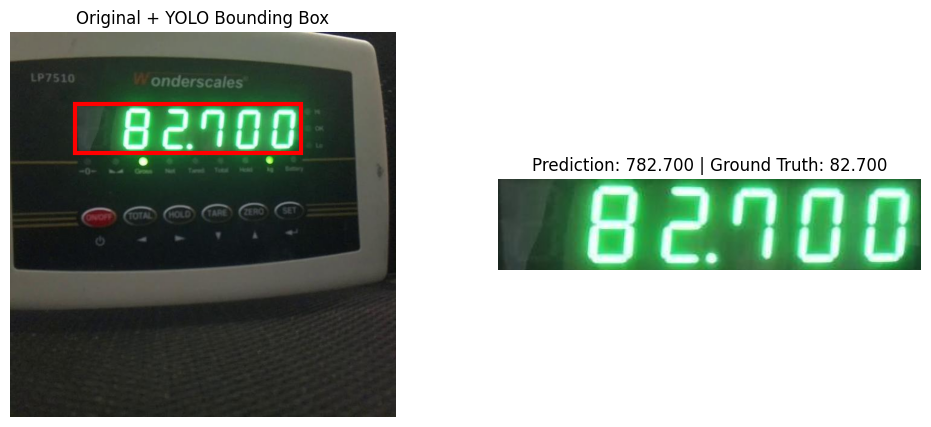

Total Images Evaluated : 99
Exact Matches          : 65
Model Accuracy         : 65.66%
Character Error Rate   : 10.44%


In [9]:
import os
import cv2
import pandas as pd
import torch
import Levenshtein
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms as T
from ultralytics import YOLO

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


yolo = YOLO('/kaggle/input/datasets/princemridul/pt-ckpt/best_yolo.pt') 

parseq = torch.hub.load('baudm/parseq', 'parseq', pretrained=True).eval().to(DEVICE)

parseq_transform = T.Compose([
    T.Resize((32, 128), T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize(0.5, 0.5)
])


CSV_PATH = '/kaggle/input/datasets/princemridul/labeled-lp7510/auto_labeled_100 (1).csv'
df = pd.read_csv(CSV_PATH, dtype={'label': str})

IMAGE_DIR = '/kaggle/working/LP7510-Numbers-ROI-+-OCR-4/valid/images'

first_row = df.iloc[0]
img_name = first_row['filename']
gt_text = str(first_row['label']).strip()
img_path = os.path.join(IMAGE_DIR, img_name)

img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

results = yolo(img_rgb, verbose=False)
boxes = results[0].boxes.xyxy.cpu().numpy()

pred_text = ""
cropped_img = None

if len(boxes) > 0:
    x1, y1, x2, y2 = map(int, boxes[0])
    cropped_img = img_rgb[y1:y2, x1:x2]
    

    pil_crop = Image.fromarray(cropped_img)
    img_tensor = parseq_transform(pil_crop).unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        logits = parseq(img_tensor)
        pred = logits.softmax(-1)
        label_out, _ = parseq.tokenizer.decode(pred)
        pred_text = label_out[0].strip()


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_rgb)
if len(boxes) > 0:
    rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='red', linewidth=3)
    axes[0].add_patch(rect)
axes[0].set_title("Original + YOLO Bounding Box")
axes[0].axis('off')

if cropped_img is not None:
    axes[1].imshow(cropped_img)
axes[1].set_title(f"Prediction: {pred_text} | Ground Truth: {gt_text}")
axes[1].axis('off')
plt.show()

#print("Crunching through the full 100-image Gold Standard dataset...")
exact_matches = 0
total_chars = 0
total_errors = 0

for index, row in df.iterrows():
    img_name = row['filename']
    gt_text = str(row['label']).strip()
    img_path = os.path.join(IMAGE_DIR, img_name)
    
    img = cv2.imread(img_path)
    if img is None:
        continue
        
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    pred_text = ""
    results = yolo(img_rgb, verbose=False)
    boxes = results[0].boxes.xyxy.cpu().numpy()
    
    if len(boxes) > 0:
        x1, y1, x2, y2 = map(int, boxes[0])
        cropped_img = img_rgb[y1:y2, x1:x2]
        
        pil_crop = Image.fromarray(cropped_img)
        img_tensor = parseq_transform(pil_crop).unsqueeze(0).to(DEVICE)
        
        with torch.no_grad():
            logits = parseq(img_tensor)
            pred = logits.softmax(-1)
            label_out, _ = parseq.tokenizer.decode(pred)
            pred_text = label_out[0].strip()
    
    
    if pred_text == gt_text:
        exact_matches += 1
        
    edit_dist = Levenshtein.distance(pred_text, gt_text)
    total_errors += edit_dist
    total_chars += len(gt_text)

accuracy = (exact_matches / len(df)) * 100
cer = (total_errors / total_chars) * 100 if total_chars > 0 else 0

print(f"Total Images Evaluated : {len(df)}")
print(f"Exact Matches          : {exact_matches}")
print(f"Model Accuracy         : {accuracy:.2f}%")
print(f"Character Error Rate   : {cer:.2f}%")

In [10]:
import pandas as pd
import os
import cv2
import torch
from ultralytics import YOLO
from PIL import Image
from torchvision import transforms as T

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
yolo = YOLO('/kaggle/input/datasets/princemridul/pt-ckpt/best_yolo.pt')
parseq = torch.hub.load('baudm/parseq', 'parseq', pretrained=True).eval().to(DEVICE)
parseq_transform = T.Compose([T.Resize((32, 128), T.InterpolationMode.BICUBIC), T.ToTensor(), T.Normalize(0.5, 0.5)])

df = pd.read_csv('/kaggle/input/datasets/princemridul/labeled-lp7510/auto_labeled_100 (1).csv', dtype={'label': str})
IMAGE_DIR = '/kaggle/working/LP7510-Numbers-ROI-+-OCR-4/valid/images'

results_list = []

for index, row in df.iterrows():
    img_name = row['filename']
    gt_text = str(row['label']).strip()
    
    img = cv2.imread(os.path.join(IMAGE_DIR, img_name))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    
    yolo_res = yolo(img_rgb, verbose=False)
    boxes = yolo_res[0].boxes.xyxy.cpu().numpy()
    
    pred_text = "NO_DETECTION"
    if len(boxes) > 0:
        x1, y1, x2, y2 = map(int, boxes[0])
        crop = Image.fromarray(img_rgb[y1:y2, x1:x2])
        img_tensor = parseq_transform(crop).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            logits = parseq(img_tensor)
            pred = logits.softmax(-1)
            label_out, _ = parseq.tokenizer.decode(pred)
            pred_text = label_out[0].strip()
    
    status = "MATCH" if pred_text == gt_text else "MISMATCH"
    results_list.append({"filename": img_name, "ground_truth": gt_text, "prediction": pred_text, "status": status})

df_comparison = pd.DataFrame(results_list)
df_comparison.to_csv('/kaggle/working/benchmark_comparison.csv', index=False)
print("Benchmark complete! Download 'benchmark_comparison.csv' from the sidebar.")

Using cache found in /root/.cache/torch/hub/baudm_parseq_main


Benchmark complete! Download 'benchmark_comparison.csv' from the sidebar.


Using cache found in /root/.cache/torch/hub/baudm_parseq_main


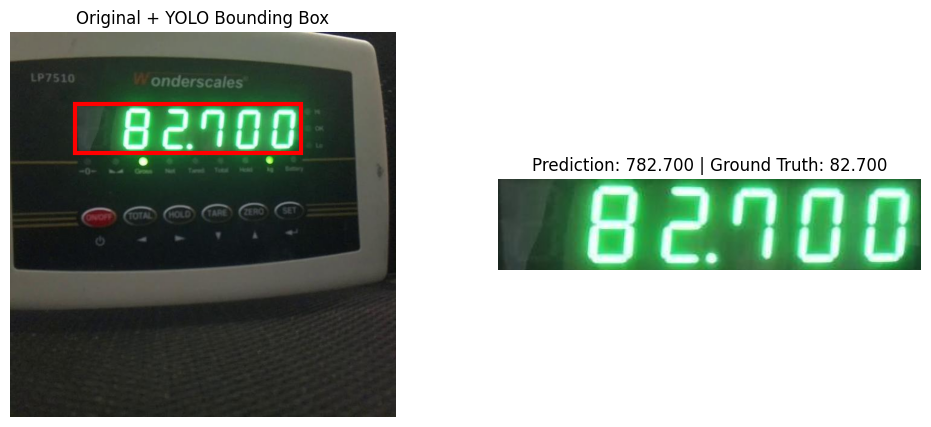

Total Images Evaluated : 99
Exact Matches          : 75
Model Accuracy         : 75.76%
Character Error Rate   : 5.72%


In [13]:
import os
import cv2
import pandas as pd
import torch
import Levenshtein
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms as T
from ultralytics import YOLO

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


yolo = YOLO('/kaggle/input/datasets/princemridul/pt-ckpt/best_yolo.pt') 


parseq = torch.hub.load('baudm/parseq', 'parseq', pretrained=True).eval().to(DEVICE)

parseq_transform = T.Compose([
    T.Resize((32, 128), T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize(0.5, 0.5)
])


CSV_PATH = '/kaggle/input/datasets/princemridul/labeled-images-updated/auto_labeled_100 (1).csv'
df = pd.read_csv(CSV_PATH, dtype={'label': str})

IMAGE_DIR = '/kaggle/working/LP7510-Numbers-ROI-+-OCR-4/valid/images'

first_row = df.iloc[0]
img_name = first_row['filename']
gt_text = str(first_row['label']).strip()
img_path = os.path.join(IMAGE_DIR, img_name)

img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

results = yolo(img_rgb, verbose=False)
boxes = results[0].boxes.xyxy.cpu().numpy()

pred_text = ""
cropped_img = None

if len(boxes) > 0:
    x1, y1, x2, y2 = map(int, boxes[0])
    cropped_img = img_rgb[y1:y2, x1:x2]
    

    pil_crop = Image.fromarray(cropped_img)
    img_tensor = parseq_transform(pil_crop).unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        logits = parseq(img_tensor)
        pred = logits.softmax(-1)
        label_out, _ = parseq.tokenizer.decode(pred)
        pred_text = label_out[0].strip()


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_rgb)
if len(boxes) > 0:
    rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='red', linewidth=3)
    axes[0].add_patch(rect)
axes[0].set_title("Original + YOLO Bounding Box")
axes[0].axis('off')

if cropped_img is not None:
    axes[1].imshow(cropped_img)
axes[1].set_title(f"Prediction: {pred_text} | Ground Truth: {gt_text}")
axes[1].axis('off')
plt.show()

exact_matches = 0
total_chars = 0
total_errors = 0

for index, row in df.iterrows():
    img_name = row['filename']
    gt_text = str(row['label']).strip()
    img_path = os.path.join(IMAGE_DIR, img_name)
    
    img = cv2.imread(img_path)
    if img is None:
        continue
        
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    pred_text = ""
    results = yolo(img_rgb, verbose=False)
    boxes = results[0].boxes.xyxy.cpu().numpy()
    
    if len(boxes) > 0:
        x1, y1, x2, y2 = map(int, boxes[0])
        cropped_img = img_rgb[y1:y2, x1:x2]
        
        pil_crop = Image.fromarray(cropped_img)
        img_tensor = parseq_transform(pil_crop).unsqueeze(0).to(DEVICE)
        
        with torch.no_grad():
            logits = parseq(img_tensor)
            pred = logits.softmax(-1)
            label_out, _ = parseq.tokenizer.decode(pred)
            pred_text = label_out[0].strip()
    
    
    if pred_text == gt_text:
        exact_matches += 1
        
    edit_dist = Levenshtein.distance(pred_text, gt_text)
    total_errors += edit_dist
    total_chars += len(gt_text)

accuracy = (exact_matches / len(df)) * 100
cer = (total_errors / total_chars) * 100 if total_chars > 0 else 0

print(f"Total Images Evaluated : {len(df)}")
print(f"Exact Matches          : {exact_matches}")
print(f"Model Accuracy         : {accuracy:.2f}%")
print(f"Character Error Rate   : {cer:.2f}%")

In [12]:
import pandas as pd
import os
import cv2
import torch
import Levenshtein
from ultralytics import YOLO
from PIL import Image
from torchvision import transforms as T

def preprocess_crop(crop_img):
    
    h, w = crop_img.shape[:2]
    
    
    x_trim = int(w * 0.04)
    y_trim = int(h * 0.02)
    trimmed = crop_img[y_trim:h-y_trim, x_trim:w-x_trim]
    
    
    img_yuv = cv2.cvtColor(trimmed, cv2.COLOR_RGB2YUV)
    
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    img_yuv[:,:,0] = clahe.apply(img_yuv[:,:,0])
    
    enhanced_crop = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)
    
    return enhanced_crop

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
yolo = YOLO('/kaggle/input/datasets/princemridul/pt-ckpt/best_yolo.pt')
parseq = torch.hub.load('baudm/parseq', 'parseq', pretrained=True).eval().to(DEVICE)
parseq_transform = T.Compose([T.Resize((32, 128), T.InterpolationMode.BICUBIC), T.ToTensor(), T.Normalize(0.5, 0.5)])


df = pd.read_csv('/kaggle/input/datasets/princemridul/labeled-images-updated/auto_labeled_100 (1).csv', dtype={'label': str})
IMAGE_DIR = '/kaggle/working/LP7510-Numbers-ROI-+-OCR-4/valid/images'

results_list = []
exact_matches = 0
total_chars = 0
total_errors = 0

print("Running Enhanced Pipeline with CLAHE Pre-processing...")


for index, row in df.iterrows():
    img_name = row['filename']
    gt_text = str(row['label']).strip()
    
    img = cv2.imread(os.path.join(IMAGE_DIR, img_name))
    if img is None: continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    
    yolo_res = yolo(img_rgb, verbose=False)
    boxes = yolo_res[0].boxes.xyxy.cpu().numpy()
    
    pred_text = "NO_DETECTION"
    if len(boxes) > 0:
        x1, y1, x2, y2 = map(int, boxes[0])
        
        
        raw_crop = img_rgb[y1:y2, x1:x2]
        
        
        clean_crop = preprocess_crop(raw_crop)
        
        
        pil_crop = Image.fromarray(clean_crop)
        img_tensor = parseq_transform(pil_crop).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            logits = parseq(img_tensor)
            pred = logits.softmax(-1)
            label_out, _ = parseq.tokenizer.decode(pred)
            pred_text = label_out[0].strip()
    
    
    status = "MATCH" if pred_text == gt_text else "MISMATCH"
    results_list.append({"filename": img_name, "ground_truth": gt_text, "prediction": pred_text, "status": status})
    
    if status == "MATCH":
        exact_matches += 1
    total_errors += Levenshtein.distance(pred_text, gt_text)
    total_chars += len(gt_text)


df_comparison = pd.DataFrame(results_list)
df_comparison.to_csv('/kaggle/working/enhanced_benchmark_comparison.csv', index=False)

accuracy = (exact_matches / len(df)) * 100
cer = (total_errors / total_chars) * 100 if total_chars > 0 else 0


print(f"Total Images   : {len(df)}")
print(f"Exact Matches  : {exact_matches}")
print(f"Model Accuracy : {accuracy:.2f}%")
print(f"CER            : {cer:.2f}%")


Using cache found in /root/.cache/torch/hub/baudm_parseq_main


Running Enhanced Pipeline with CLAHE Pre-processing...
Total Images   : 99
Exact Matches  : 20
Model Accuracy : 20.20%
CER            : 17.34%


Running on: cpu


Using cache found in /root/.cache/torch/hub/baudm_parseq_main



 VISUALIZING PRE-PROCESSING ON IMAGE #1...


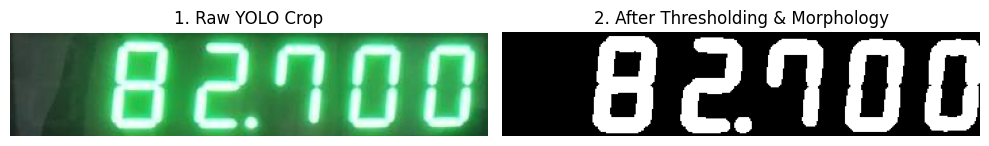

Total Images   : 99
Exact Matches  : 13
Model Accuracy : 13.13%
CER            : 19.70%


In [15]:
import pandas as pd
import os
import cv2
import torch
import Levenshtein
import matplotlib.pyplot as plt
from ultralytics import YOLO
from PIL import Image
from torchvision import transforms as T

def preprocess_crop(crop_img):
    """
    Strips background noise and bridges 7-segment gaps using Morphology.
    """
    
    h, w = crop_img.shape[:2]
    x_trim = int(w * 0.03)
    y_trim = int(h * 0.03)
    trimmed = crop_img[y_trim:h-y_trim, x_trim:w-x_trim]
    
    
    gray = cv2.cvtColor(trimmed, cv2.COLOR_RGB2GRAY)
    
    
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    
    processed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
   
    processed = cv2.dilate(processed, kernel, iterations=1)
    
   
    final_crop = cv2.cvtColor(processed, cv2.COLOR_GRAY2RGB)
    
    return final_crop

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on: {DEVICE}")
yolo = YOLO('/kaggle/input/datasets/princemridul/pt-ckpt/best_yolo.pt')
parseq = torch.hub.load('baudm/parseq', 'parseq', pretrained=True).eval().to(DEVICE)
parseq_transform = T.Compose([T.Resize((32, 128), T.InterpolationMode.BICUBIC), T.ToTensor(), T.Normalize(0.5, 0.5)])


df = pd.read_csv('/kaggle/input/datasets/princemridul/labeled-images-updated/auto_labeled_100 (1).csv', dtype={'label': str})
IMAGE_DIR = '/kaggle/working/LP7510-Numbers-ROI-+-OCR-4/valid/images'


print("\n VISUALIZING PRE-PROCESSING ON IMAGE #1...")
first_img_name = df.iloc[0]['filename']
test_img = cv2.imread(os.path.join(IMAGE_DIR, first_img_name))
test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)

yolo_res = yolo(test_img_rgb, verbose=False)
boxes = yolo_res[0].boxes.xyxy.cpu().numpy()

if len(boxes) > 0:
    x1, y1, x2, y2 = map(int, boxes[0])
    raw_crop = test_img_rgb[y1:y2, x1:x2]
    clean_crop = preprocess_crop(raw_crop)
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(raw_crop)
    axes[0].set_title("1. Raw YOLO Crop")
    axes[0].axis('off')
    
    axes[1].imshow(clean_crop)
    axes[1].set_title("2. After Thresholding & Morphology")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("YOLO found no boxes in the first image to visualize.")


results_list = []
exact_matches = 0
total_chars = 0
total_errors = 0


for index, row in df.iterrows():
    img_name = row['filename']
    gt_text = str(row['label']).strip()
    
    img = cv2.imread(os.path.join(IMAGE_DIR, img_name))
    if img is None: continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    yolo_res = yolo(img_rgb, verbose=False)
    boxes = yolo_res[0].boxes.xyxy.cpu().numpy()
    
    pred_text = "NO_DETECTION"
    if len(boxes) > 0:
        x1, y1, x2, y2 = map(int, boxes[0])
        raw_crop = img_rgb[y1:y2, x1:x2]
        
        
        clean_crop = preprocess_crop(raw_crop)
        
        
        pil_crop = Image.fromarray(clean_crop)
        img_tensor = parseq_transform(pil_crop).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            logits = parseq(img_tensor)
            pred = logits.softmax(-1)
            label_out, _ = parseq.tokenizer.decode(pred)
            pred_text = label_out[0].strip()
    
   
    status = "MATCH" if pred_text == gt_text else "MISMATCH"
    results_list.append({"filename": img_name, "ground_truth": gt_text, "prediction": pred_text, "status": status})
    
    if status == "MATCH":
        exact_matches += 1
    total_errors += Levenshtein.distance(pred_text, gt_text)
    total_chars += len(gt_text)


df_comparison = pd.DataFrame(results_list)
df_comparison.to_csv('/kaggle/working/threshold_benchmark_comparison.csv', index=False)

accuracy = (exact_matches / len(df)) * 100
cer = (total_errors / total_chars) * 100 if total_chars > 0 else 0


print(f"Total Images   : {len(df)}")
print(f"Exact Matches  : {exact_matches}")
print(f"Model Accuracy : {accuracy:.2f}%")
print(f"CER            : {cer:.2f}%")


In [16]:
import pandas as pd
import os
import cv2
import numpy as np
import torch
import Levenshtein
from ultralytics import YOLO
from PIL import Image
from torchvision import transforms as T

def preprocess_crop(crop_img):
    
    h, w = crop_img.shape[:2]
    x_trim = int(w * 0.04)
    y_trim = int(h * 0.04)
    trimmed = crop_img[y_trim:h-y_trim, x_trim:w-x_trim]

    
    gamma = 0.5
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    enhanced = cv2.LUT(trimmed, table)

    
    kernel = np.array([[0, -1,  0], 
                       [-1,  5, -1], 
                       [0, -1,  0]])
    final_crop = cv2.filter2D(enhanced, -1, kernel)

    return final_crop

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
yolo = YOLO('/kaggle/input/datasets/princemridul/pt-ckpt/best_yolo.pt')
parseq = torch.hub.load('baudm/parseq', 'parseq', pretrained=True).eval().to(DEVICE)
parseq_transform = T.Compose([T.Resize((32, 128), T.InterpolationMode.BICUBIC), T.ToTensor(), T.Normalize(0.5, 0.5)])

df = pd.read_csv('/kaggle/input/datasets/princemridul/labeled-images-updated/auto_labeled_100 (1).csv', dtype={'label': str})
IMAGE_DIR = '/kaggle/working/LP7510-Numbers-ROI-+-OCR-4/valid/images'

results = []
matches = 0
total_chars = 0
total_dist = 0

for _, row in df.iterrows():
    img_path = os.path.join(IMAGE_DIR, row['filename'])
    img = cv2.imread(img_path)
    if img is None:
        continue
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    yolo_res = yolo(img_rgb, verbose=False)
    boxes = yolo_res[0].boxes.xyxy.cpu().numpy()
    
    pred = ""
    if len(boxes) > 0:
        x1, y1, x2, y2 = map(int, boxes[0])
        raw_crop = img_rgb[y1:y2, x1:x2]
        clean_crop = preprocess_crop(raw_crop)
        
        with torch.no_grad():
            tensor = parseq_transform(Image.fromarray(clean_crop)).unsqueeze(0).to(DEVICE)
            logits = parseq(tensor)
            decoded, _ = parseq.tokenizer.decode(logits.softmax(-1))
            pred = decoded[0].strip()
            
    gt = str(row['label']).strip()
    results.append({'filename': row['filename'], 'ground_truth': gt, 'prediction': pred})
    
    if pred == gt:
        matches += 1
    total_dist += Levenshtein.distance(pred, gt)
    total_chars += len(gt)

pd.DataFrame(results).to_csv('/kaggle/working/gamma_benchmark.csv', index=False)

accuracy = (matches / len(df)) * 100
cer = (total_dist / total_chars) * 100 if total_chars > 0 else 0

print(f"Accuracy: {accuracy:.2f}%")
print(f"CER: {cer:.2f}%")

Using cache found in /root/.cache/torch/hub/baudm_parseq_main


Accuracy: 39.39%
CER: 11.45%


In [17]:
import pandas as pd
import os
import cv2
import torch
import Levenshtein
import re
from ultralytics import YOLO
from PIL import Image
from torchvision import transforms as T

def clean_crop(img):

    h, w = img.shape[:2]
    x_trim = int(w * 0.03)
    y_trim = int(h * 0.03)
    return img[y_trim:h-y_trim, x_trim:w-x_trim]

def post_process_prediction(pred):
    
    clean = re.sub(r'[^0-9\.]', '', pred)
    
    if '.' not in clean and len(clean) >= 4:
        clean = clean[:-3] + '.' + clean[-3:]
        
    parts = clean.split('.')
    if len(parts) == 2 and len(parts[0]) > 2:
        clean = parts[0][-2:] + '.' + parts[1]
        
    return clean

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
yolo = YOLO('/kaggle/input/datasets/princemridul/pt-ckpt/best_yolo.pt')
parseq = torch.hub.load('baudm/parseq', 'parseq', pretrained=True).eval().to(DEVICE)
parseq_transform = T.Compose([T.Resize((32, 128), T.InterpolationMode.BICUBIC), T.ToTensor(), T.Normalize(0.5, 0.5)])

df = pd.read_csv('/kaggle/input/datasets/princemridul/labeled-images-updated/auto_labeled_100 (1).csv', dtype={'label': str})
IMAGE_DIR = '/kaggle/working/LP7510-Numbers-ROI-+-OCR-4/valid/images'

results = []
matches = 0
total_chars = 0
total_dist = 0

for _, row in df.iterrows():
    img_path = os.path.join(IMAGE_DIR, row['filename'])
    img = cv2.imread(img_path)
    if img is None:
        continue
        
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    yolo_res = yolo(img_rgb, verbose=False)
    boxes = yolo_res[0].boxes.xyxy.cpu().numpy()
    
    pred = ""
    if len(boxes) > 0:
        x1, y1, x2, y2 = map(int, boxes[0])
        raw_crop = img_rgb[y1:y2, x1:x2]
        shaved_crop = clean_crop(raw_crop)
        
        with torch.no_grad():
            tensor = parseq_transform(Image.fromarray(shaved_crop)).unsqueeze(0).to(DEVICE)
            logits = parseq(tensor)
            decoded, _ = parseq.tokenizer.decode(logits.softmax(-1))
            raw_pred = decoded[0].strip()
            
            pred = post_process_prediction(raw_pred)
            
    gt = str(row['label']).strip()
    results.append({'filename': row['filename'], 'ground_truth': gt, 'prediction': pred})
    
    if pred == gt:
        matches += 1
    total_dist += Levenshtein.distance(pred, gt)
    total_chars += len(gt)

pd.DataFrame(results).to_csv('/kaggle/working/heuristic_benchmark.csv', index=False)

accuracy = (matches / len(df)) * 100
cer = (total_dist / total_chars) * 100 if total_chars > 0 else 0

print(f"Accuracy: {accuracy:.2f}%")
print(f"CER: {cer:.2f}%")

Using cache found in /root/.cache/torch/hub/baudm_parseq_main


Accuracy: 90.91%
CER: 1.68%
